## Import libraries

In [2]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np
from skimage.transform import pyramid_gaussian
from scipy.ndimage import zoom

def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    #Shift angles to be centered around 0
    angles = angles - np.mean(angles)
    return projs, angles


No usable GPU detected — running CPU-only.


## Import real Data

In [3]:
import os

downsample = 4
recon_alg = 'gridrec'
# filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
filename = "/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5"

cached_filename = filename.replace(".hdf5", f"_ds{downsample}.hdf5")

if os.path.exists(cached_filename):
    print(f"Loading downsampled cache: {cached_filename}")
    projections, angles = tomo_data(cached_filename)
    print(projections.shape)
    tomo = tomoData(projections, angles)
else:
# if True:
    print("Cache not found — loading full dataset...")
    projections_og, angles = tomo_data(filename, redo_align=True)
    print("Full dataset shape:", projections_og.shape)

    #Remove projection and angle 26
    projections_og = np.delete(projections_og, 26, axis=0)
    angles = np.delete(angles, 26)

    #Remove projection and angle 19
    projections_og = np.delete(projections_og, 19, axis=0)
    angles = np.delete(angles, 19)
    _needs_downsample = True

if not os.path.exists(cached_filename):
# if True:
    print("Downsampling...")
    projections = zoom(projections_og, (1, 1/downsample, 1/downsample), order=1)
    print(projections.shape)

    print(f"Saving downsampled cache to: {cached_filename}")
    with h5py.File(cached_filename, 'w') as hf:
        hf.create_dataset('data', data=projections)
        hf.create_dataset('angles', data=angles * 180 / np.pi)  # save back in degrees

    tomo = tomoData(projections, angles)

num_angles = projections.shape[0] if os.path.exists(cached_filename) else projections_og.shape[0]
print(f"Number of angles: {num_angles}")

Loading downsampled cache: /home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2_ds4.hdf5
(556, 146, 452)
Number of angles: 556


In [4]:
print(projections.shape)
tomo.makeNotebookProjMovie()

(556, 146, 452)


Output()

## Align Data

In [ ]:
# # Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
# tomo.normalize(isPhaseData=True)

# tomo.reconstruct(algorithm=recon_alg)
# print("\nBad reconstruction prior to alignment")
# badRecon = tomo.recon.copy()
# MoviePlotter(badRecon)

In [ ]:
# # Reprojection Consistency Score — before alignment
# rcs_before, _, _ = tomo.reprojection_consistency_score(plot=False)

# #Sinogram consistency score — before alignment
# scs_before, _, _, _, _ = tomo.sinogram_consistency_score(plot=False)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | ROI y=[0, 146] x=[0, 452] | gradient mode]


Iteration 1/5: 100%|██████████| 555/555 [00:04<00:00, 112.28it/s]


  Projection 278 shift: y=3.2000 px, x=-28.4800 px


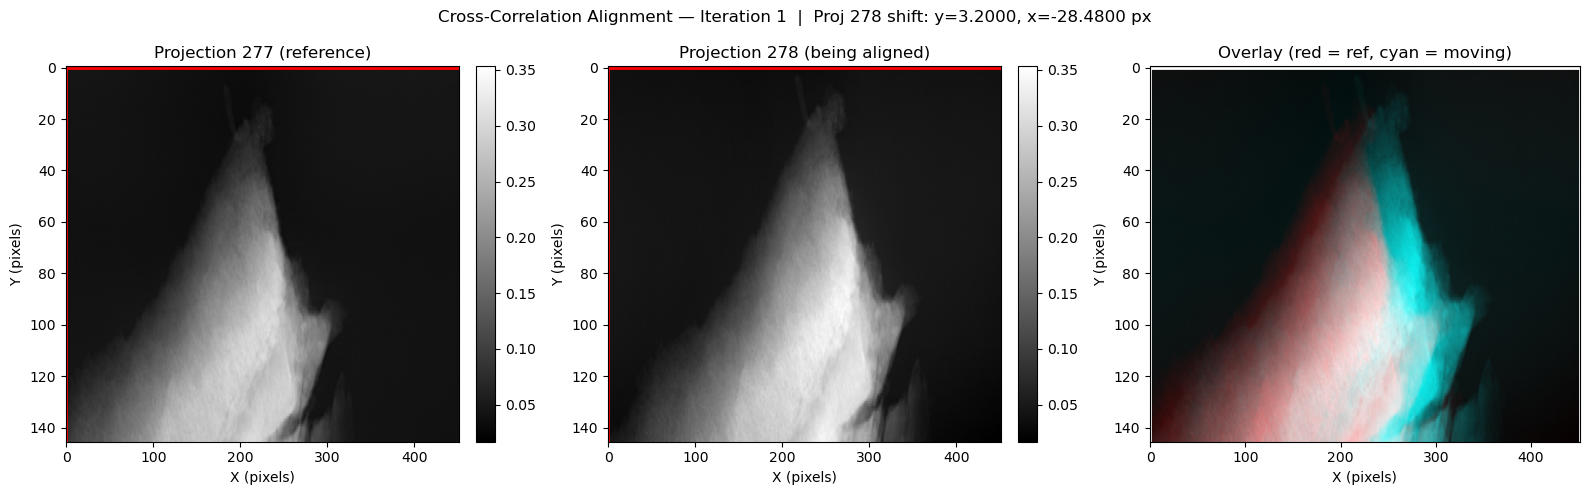

Iteration 1: avg shift = 16.6565 px, max shift = 82.9147 px


Iteration 2/5: 100%|██████████| 555/555 [00:04<00:00, 116.00it/s]


Iteration 2: avg shift = 3.6836 px, max shift = 19.5907 px


Iteration 3/5: 100%|██████████| 555/555 [00:04<00:00, 118.59it/s]


Iteration 3: avg shift = 0.8181 px, max shift = 16.2240 px


...

Iteration 5/5: 100%|██████████| 555/555 [00:04<00:00, 119.68it/s]


Iteration 5: avg shift = 0.2955 px, max shift = 11.6273 px
Maximum iterations reached without convergence.
Centering Projections
Original center: 226.0
Center of frame: 226
Aligned projections shifted by 0.0 pixels
Projections are currently centered at pixel 226.0. Residual offset: 0.0


Apply shifts to final projections: 100%|██████████| 556/556 [00:07<00:00, 72.28it/s]

Largest shifts per direction:
  Top    (down  51.52 px) — projection 51
  Bottom (up    20.64 px) — projection 493
  Left   (right 54.56 px) — projection 404
  Right  (left  117.92 px) — projection 264


Output()

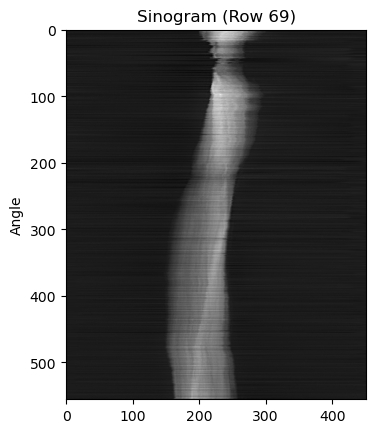

In [5]:
tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

# XCA Pass 1 - coarse (downsample=4)
tomo.cross_correlate_align(
    tolerance=0.001, maxShiftTolerance=0.5, max_iterations=5, stepRatio=0.8,
    downsample=4, use_grad=True,
    yROI_Range=None, xROI_Range=None, isFull360=False, plot=True
)
tomo.center_projections()
tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)
tomo.displayWorkingSinogram(row_index=tomo.workingProjections.shape[0] // downsample // 2)



Cross-Correlation Alignment  [2x downsample | ROI y=[0, 96] x=[62, 390] | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:03<00:00, 157.66it/s]


  Projection 278 shift: y=0.0000 px, x=0.0000 px


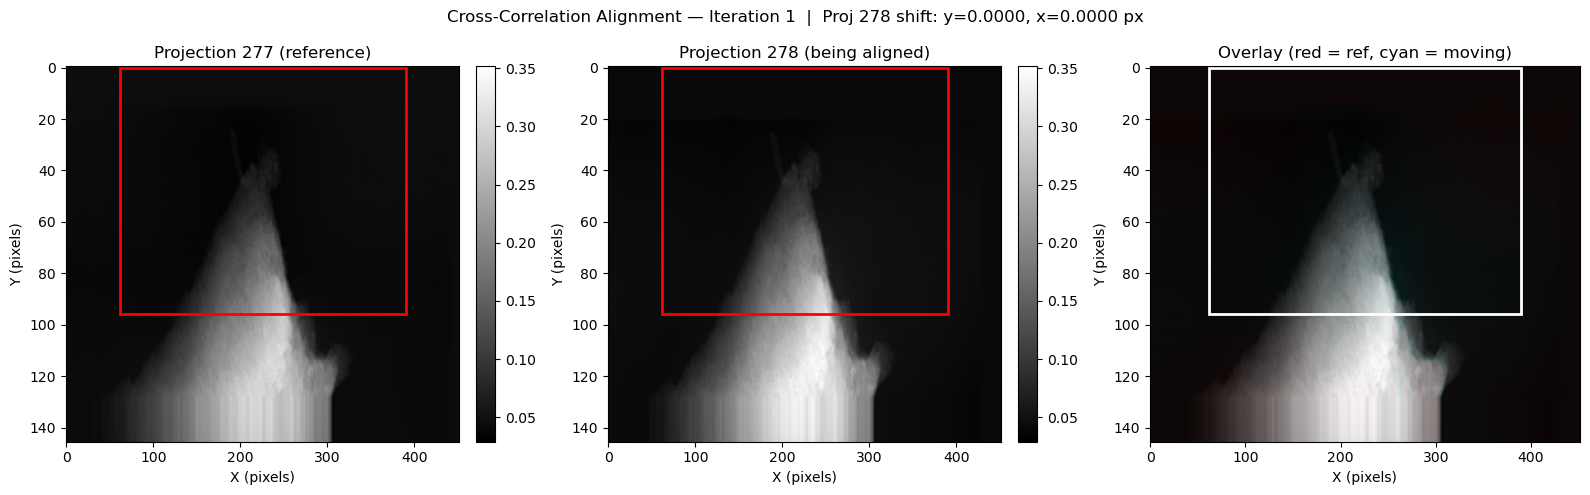

Iteration 1: avg shift = 0.7925 px, max shift = 15.6133 px


Iteration 2/10: 100%|██████████| 555/555 [00:03<00:00, 156.38it/s]


Iteration 2: avg shift = 0.2017 px, max shift = 4.2460 px


Iteration 3/10: 100%|██████████| 555/555 [00:03<00:00, 157.13it/s]


Iteration 3: avg shift = 0.1016 px, max shift = 2.2457 px


...

Iteration 10/10: 100%|██████████| 555/555 [00:03<00:00, 157.75it/s]


Iteration 10: avg shift = 0.0335 px, max shift = 1.3315 px
Maximum iterations reached without convergence.


Apply shifts to final projections: 100%|██████████| 556/556 [00:09<00:00, 56.50it/s]

Largest shifts per direction:
  Top    (down  51.52 px) — projection 51
  Bottom (up    41.68 px) — projection 51
  Left   (right 54.56 px) — projection 404
  Right  (left  117.92 px) — projection 264


Output()

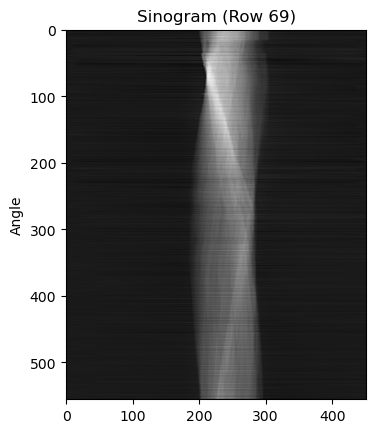

In [6]:

# XCA Pass 2 - medium
tomo.cross_correlate_align(
    tolerance=0.001, maxShiftTolerance=0.5, max_iterations=10, stepRatio=0.8,
    downsample=2, use_grad=True,
    yROI_Range=[0, tomo.workingProjections.shape[1] - (200//downsample)], xROI_Range=[250//downsample, tomo.workingProjections.shape[2] - (250 // downsample)], isFull360=False, plot=True
)
tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)
tomo.displayWorkingSinogram(row_index=tomo.workingProjections.shape[0] // downsample // 2)



Cross-Correlation Alignment  [full resolution | ROI y=[0, 71] x=[62, 390] | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:03<00:00, 157.52it/s]


  Projection 278 shift: y=-0.0400 px, x=0.3600 px


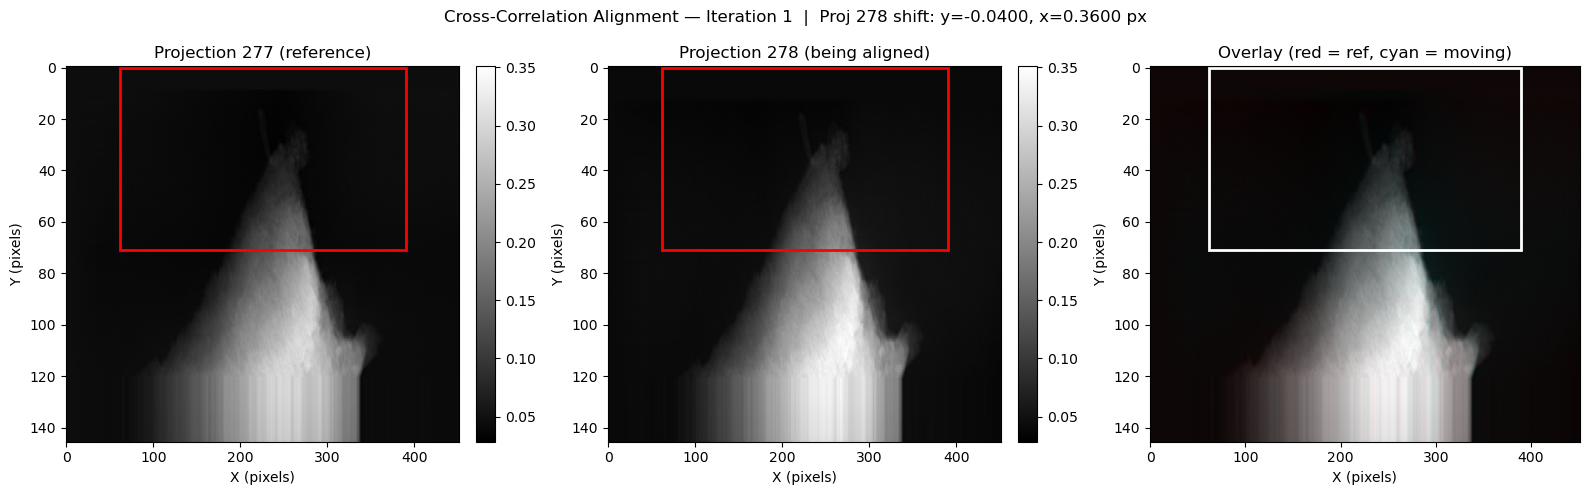

Iteration 1: avg shift = 0.3413 px, max shift = 5.7780 px


Iteration 2/10: 100%|██████████| 555/555 [00:03<00:00, 158.67it/s]


Iteration 2: avg shift = 0.0767 px, max shift = 0.9839 px


Iteration 3/10: 100%|██████████| 555/555 [00:03<00:00, 159.40it/s]


Iteration 3: avg shift = 0.0464 px, max shift = 2.0000 px


...

Iteration 10/10: 100%|██████████| 555/555 [00:03<00:00, 160.93it/s]


Iteration 10: avg shift = 0.0157 px, max shift = 0.2828 px
Maximum iterations reached without convergence.


Apply shifts to final projections: 100%|██████████| 556/556 [00:08<00:00, 68.59it/s] 


Largest shifts per direction:
  Top    (down  51.52 px) — projection 51
  Bottom (up    41.68 px) — projection 51
  Left   (right 54.56 px) — projection 404
  Right  (left  117.92 px) — projection 264


Output()

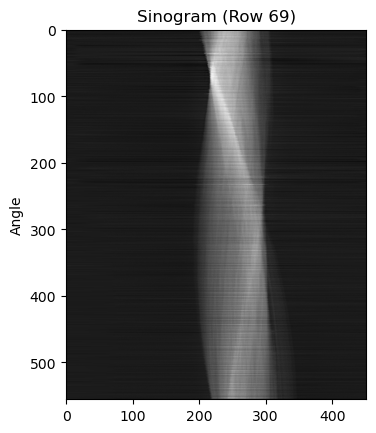

In [ ]:

tomo.cross_correlate_align(
    tolerance=0.001, maxShiftTolerance=0.5, max_iterations=10, stepRatio=0.8,
    downsample=1, use_grad=True,
    yROI_Range=[0, tomo.workingProjections.shape[1] - (300//downsample)], xROI_Range=[250//downsample, tomo.workingProjections.shape[2] - (250 // downsample)], isFull360=False, plot=True
)
tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)
tomo.displayWorkingSinogram(row_index=tomo.workingProjections.shape[0] // downsample // 2)



Projection Matching Alignment (PMA) [optical_flow | matching_preprocess]
Centering Projections
Original center: 254.25
Center of frame: 226
Aligned projections shifted by -28.25 pixels
Projections are currently centered at pixel 226.0. Residual offset: 0.0

--- PMA Level 2 (4x downsampled, 3 iterations) ---
Using ROI: x=[87, 365], y=[0, 71] (downsampled by 4x)
H and W values are 36 and 113
Downsample ROI bounds are x=21 to 91, y=0 to 17


PMA Level 2 iterations:   0%|          | 0/3 [00:00<?, ?it/s]Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

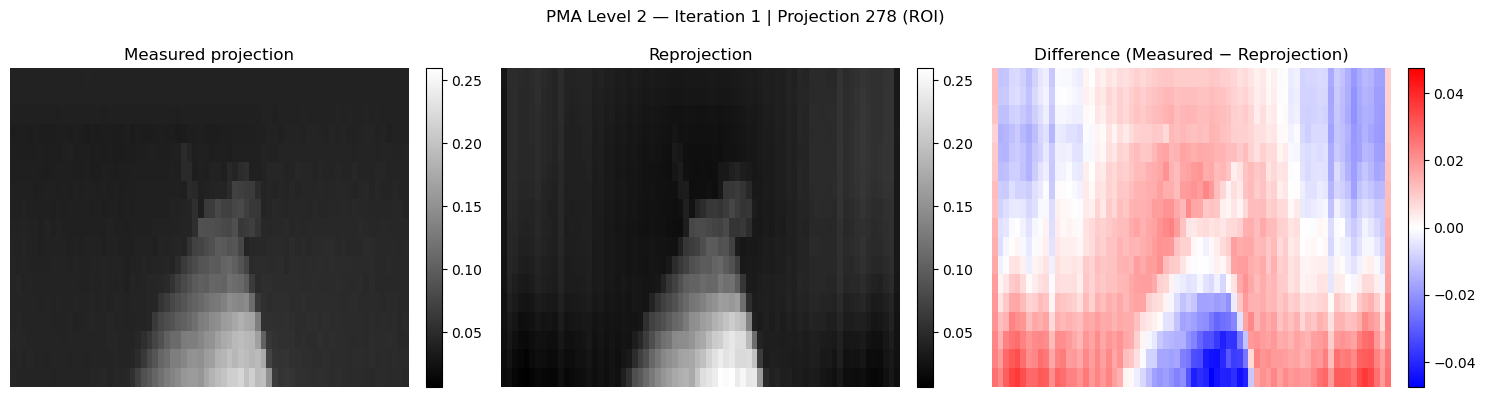

PMA Level 2 iterations:  33%|███▎      | 1/3 [00:02<00:04,  2.19s/it]

Iteration 1: avg shift = 0.5491 px, max shift = 1.4091 px


PMA Level 2 iterations:  67%|██████▋   | 2/3 [00:03<00:01,  1.87s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 2: avg shift = 0.5449 px, max shift = 1.3332 px


PMA Level 2 iterations: 100%|██████████| 3/3 [00:05<00:00,  1.85s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 3: avg shift = 0.5418 px, max shift = 1.2834 px

--- PMA Level 1 (2x downsampled, 3 iterations) ---


Using ROI: x=[87, 365], y=[0, 71] (downsampled by 2x)
H and W values are 73 and 226
Downsample ROI bounds are x=43 to 182, y=0 to 35


PMA Level 1 iterations:   0%|          | 0/3 [00:00<?, ?it/s]Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

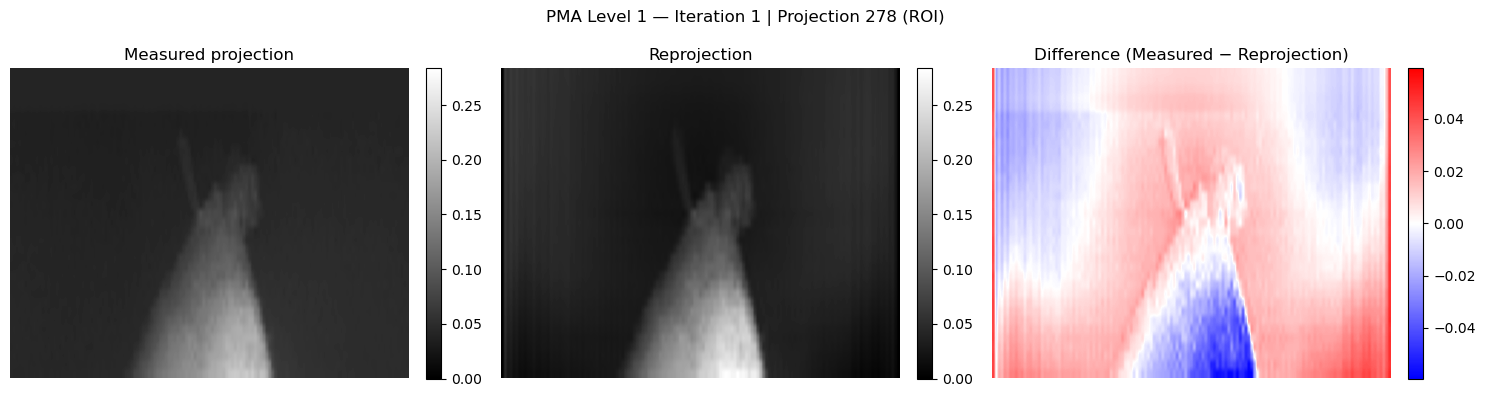

PMA Level 1 iterations:  33%|███▎      | 1/3 [00:06<00:12,  6.13s/it]

Iteration 1: avg shift = 0.3234 px, max shift = 0.7828 px


PMA Level 1 iterations:  67%|██████▋   | 2/3 [00:11<00:05,  5.43s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 2: avg shift = 0.3209 px, max shift = 0.7704 px


PMA Level 1 iterations: 100%|██████████| 3/3 [00:15<00:00,  5.16s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 3: avg shift = 0.3200 px, max shift = 0.7628 px

--- PMA Level 0 (1x downsampled, 3 iterations) ---


Using ROI: x=[87, 365], y=[0, 71] (downsampled by 1x)
H and W values are 146 and 452
Downsample ROI bounds are x=87 to 365, y=0 to 71


PMA Level 0 iterations:   0%|          | 0/3 [00:00<?, ?it/s]Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

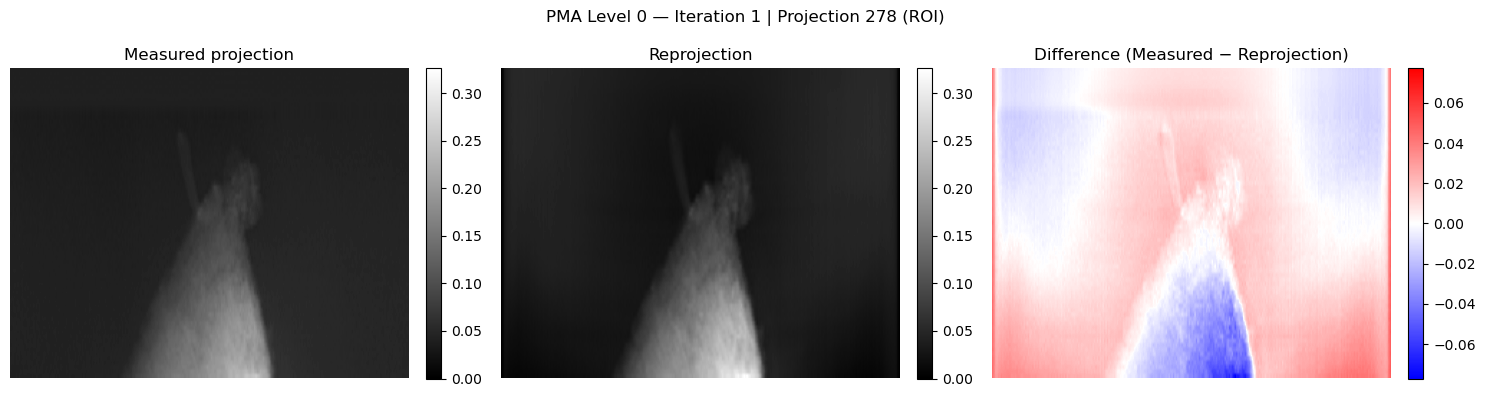

PMA Level 0 iterations:  33%|███▎      | 1/3 [00:21<00:43, 21.72s/it]

Iteration 1: avg shift = 0.1617 px, max shift = 0.4000 px


PMA Level 0 iterations:  67%|██████▋   | 2/3 [00:41<00:20, 20.51s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 2: avg shift = 0.1577 px, max shift = 0.3753 px


PMA Level 0 iterations: 100%|██████████| 3/3 [01:02<00:00, 20.95s/it]MAX_THREADS" (64)Error.  nthreads must be a positive integer

Iteration 3: avg shift = 0.1563 px, max shift = 0.3608 px



PMA complete.


Apply shifts to final projections: 100%|██████████| 556/556 [00:09<00:00, 59.69it/s]


Largest shifts per direction:
  Top    (down  51.52 px) — projection 51
  Bottom (up    41.68 px) — projection 51
  Left   (right 54.56 px) — projection 404
  Right  (left  117.92 px) — projection 264


Output()

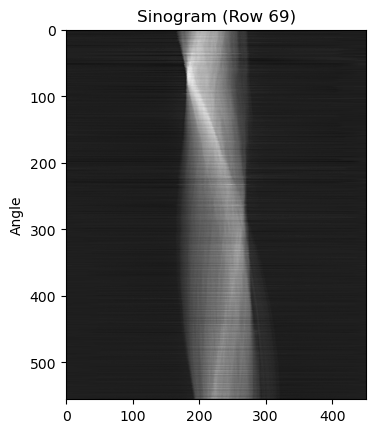

In [ ]:

# PMA - 3 levels, scale=2, of_sigma=2.0, stepRatio=0.8

#set xROI range to be width of the total number of angles divided by downsample
maxWidth = tomo.num_angles // downsample
xROI_Range = [tomo.workingProjections.shape[2] // 2 - maxWidth, tomo.workingProjections.shape[2] // 2 + maxWidth]
tomo.PMA(
    levels=3, scale=2, iterations_per_level=[5, 5, 5],
    tolerance=0.01, algorithm=recon_alg, standardize=False,
    shift_method='optical_flow', of_sigma=2.0, stepRatio=0.8, plot=True, xROI_Range=xROI_Range, yROI_Range=[0, tomo.workingProjections.shape[1] - (300//downsample)]
)

tomo.make_updates_shift()
tomo.makeNotebookProjMovie(show_trust_region=True)
tomo.displayWorkingSinogram(row_index=tomo.workingProjections.shape[0] // downsample // 2)


In [9]:
tomo.makeNotebookProjMovie()
tomo.reconstruct(algorithm=recon_alg)
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

Output()



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.

Good Reconstruction after alignment


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

Output()

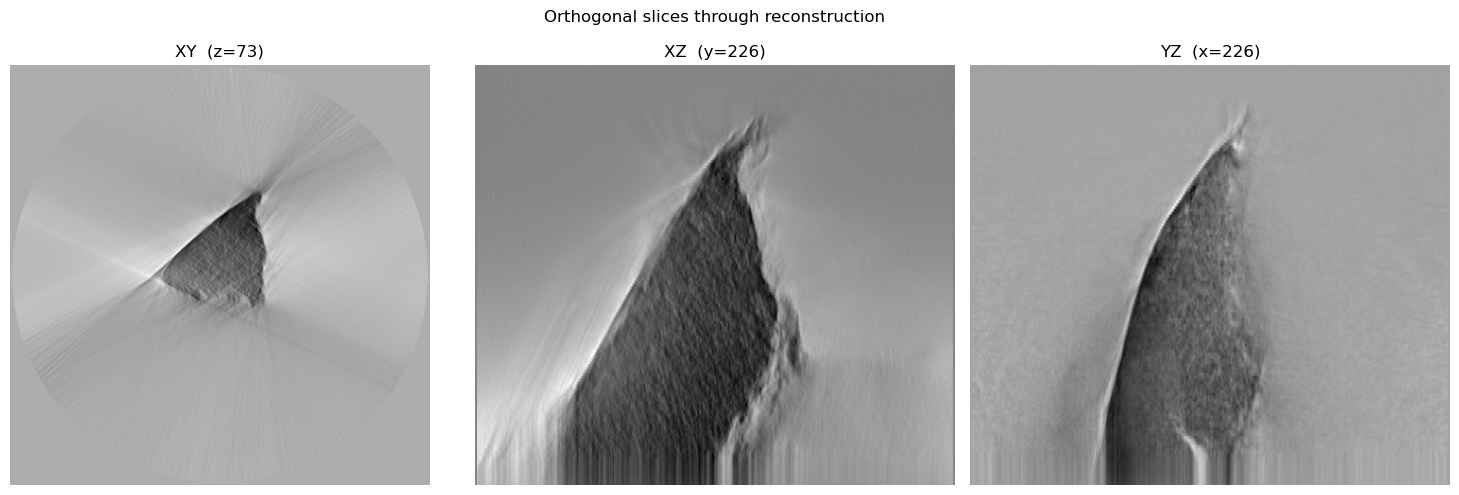

In [10]:
tomo.displayReconOrthogonalSlices()



Computing reprojections of reconstruction...


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 556/556 [00:00<00:00, 4055.26it/s]


─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.5625
  Best  angle [   9]:  NRMSE = 0.2588
  Worst angle [ 240]:  NRMSE = 1.0965
  Std across angles:  0.1336
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────




/home/ljh79/TomoMono/alignment_methods.py:1330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


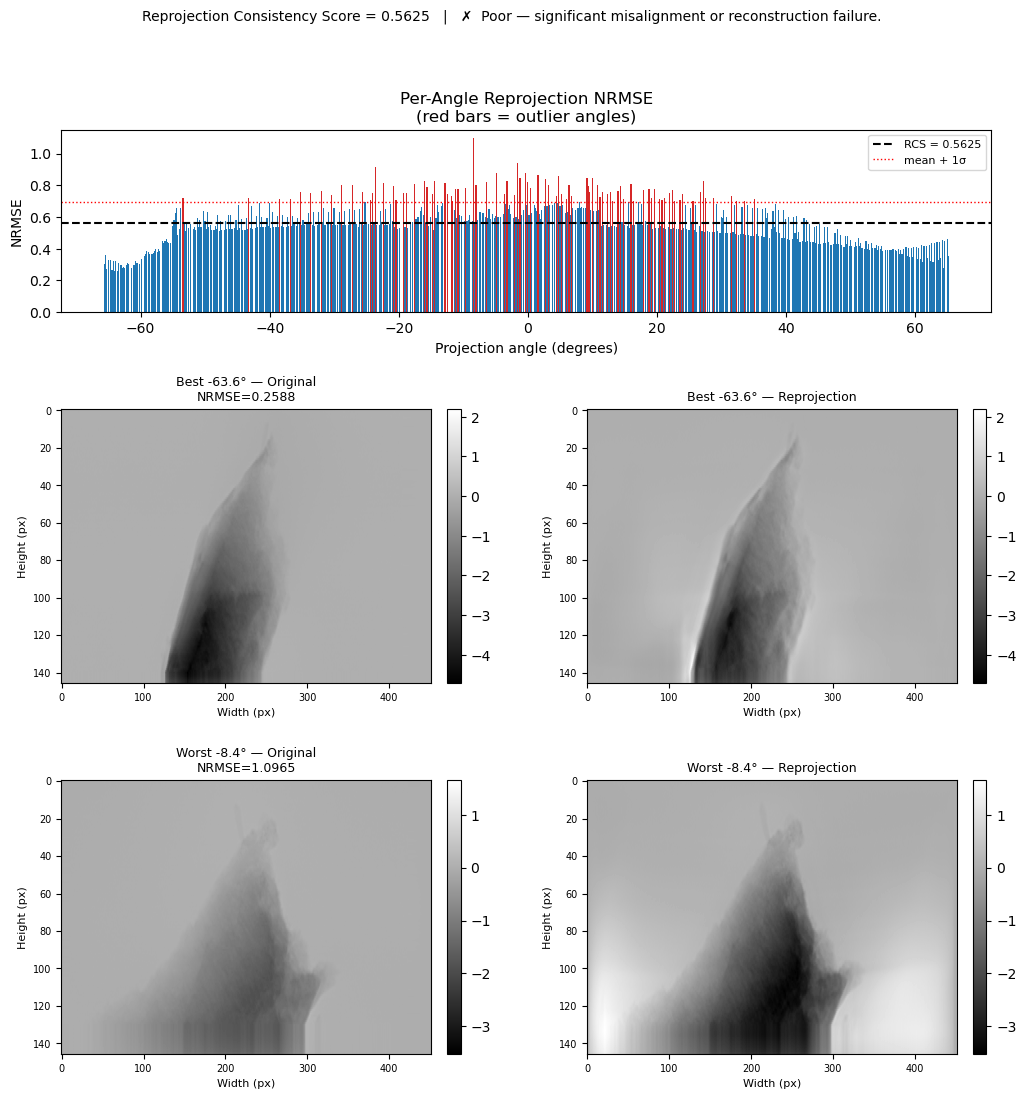



Sinogram consistency:
  x_cm (horizontal) — RMSE: 3.4931 px  |  R²: 0.930475
  y_cm (vertical)   — RMSE: 3.0006 px  |  R²: 0.000000
  Combined RMSE:       3.2562 px


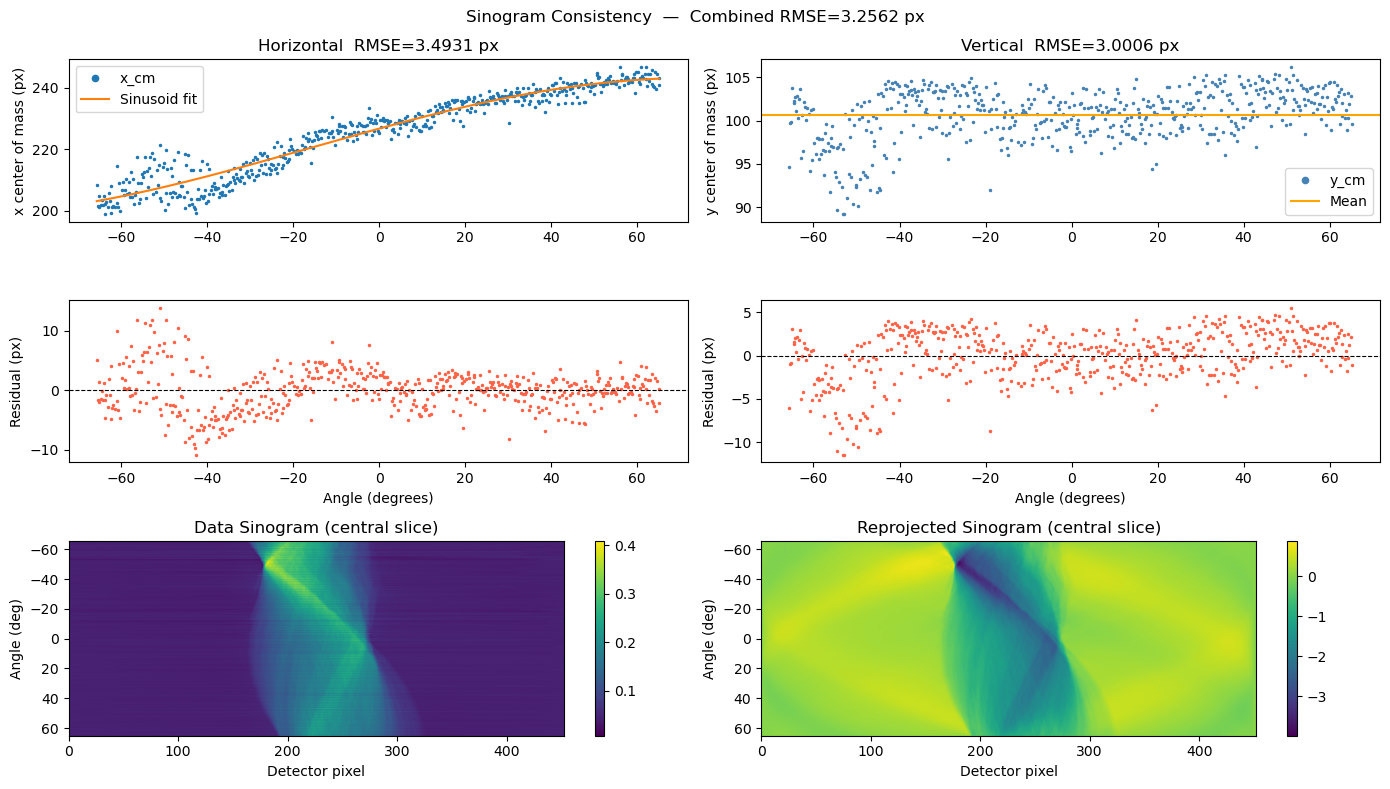




Fourier Shell Correlation  (algorithm=gridrec)
  Half 1 (even angles): 278 projections
  Half 2 (odd  angles): 278  projections
  Reconstructing half 1 …
  Reconstructing half 2 …


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integerError.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

  Computing FSC …

─── Fourier Shell Correlation ────────────────────────────────
  Volume shape (half-map): (146, 452, 452)  |  Nyquist limit: 2.0 px
  Threshold              Freq (cyc/px)  Resolution (px)
  ─────────────────────────────────────────────────────
  FSC=0.5                       0.4838             2.07
  FSC=0.143                  > Nyquist    (not reached)
  3-sigma                    > Nyquist    (not reached)
──────────────────────────────────────────────────────────────



/home/ljh79/TomoMono/alignment_methods.py:1606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


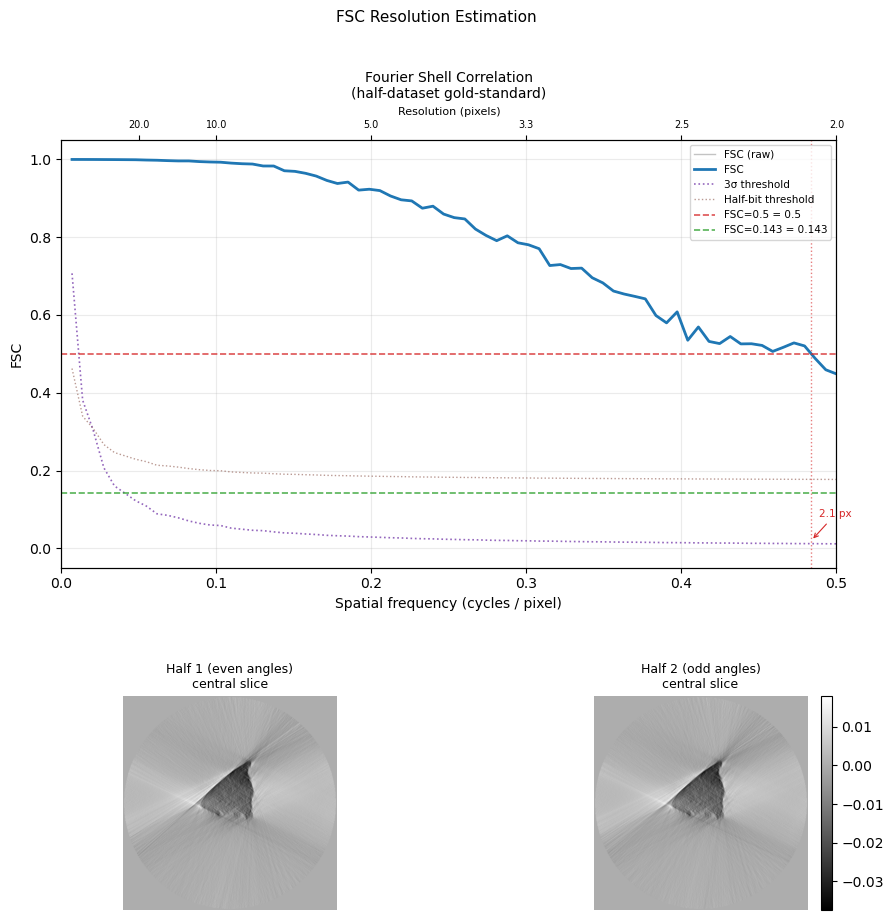

In [11]:
# Reprojection Consistency Score — after alignment
rcs_after, _, _ = tomo.reprojection_consistency_score(plot=True)

#Sinogram consistency score — after alignment
scs_after, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

#Fourier shell correlation resolution - after alignment
res_after = tomo.fourier_shell_correlation(algorithm=recon_alg, plot=True)

# # print("=" * 52)
# # print("  ALIGNMENT QUALITY SUMMARY")
# # print("=" * 52)
# # print(f"  {'Metric':<22} {'Before':>8} {'After':>8} {'Δ':>10}")
# # print(f"  {'-'*50}")
# # print(f"  {'RCS (lower = better)':<22} {rcs_before:>8.4f} {rcs_after:>8.4f} {rcs_before - rcs_after:>+10.4f}")
# # print("=" * 52)

In [12]:
import tifffile
tifffile.imwrite("bestNotebookReconstruction(4xds).tiff", tomo.recon.astype("float32"))
tifffile.imwrite("bestNotebookAlignedProjections(4xds).tiff", tomo.finalProjections.astype("float32"))